# 01 — Exploración inicial
## Proyecto final de Machine Learning — Grupo 11
### Dataset: Lending Club Loan Data

**Objetivo de este notebook:** cumplir con la exploración inicial obligatoria de la entrega previa:
carga de datos, tipos y dimensiones, % de faltantes, distribución del target, al menos 5 visualizaciones,
identificación de outliers/registros sospechosos, discusión de sesgos/leakage/limitaciones y un primer baseline simple.

**Nota sobre los datos:** este notebook asume que el archivo `accepted_2007_to_2018Q4.csv.gz`
(o el nombre equivalente del CSV de Lending Club descargado de Kaggle) está ubicado en `../data/raw/`.
El dataset no se distribuye en este repositorio por su tamaño (~1.6 GB); debe descargarse manualmente desde
https://www.kaggle.com/datasets/wordsforthewise/lending-club y colocarse en esa ruta (ver `data/README.md`).


In [ ]:

%pip install numpy
%pip install pandas

import numpy as np
import pandas as pd
%pip install matplotlib

import matplotlib.pyplot as plt
%matplotlib inline

%pip install seaborn

import seaborn as sns
%pip install -U scikit-learn

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    average_precision_score, roc_auc_score, classification_report,
    confusion_matrix, precision_recall_curve
)

np.random.seed(42)
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/flaviapalacios/dataset-original/accepted_2007_to_2018Q4.csv
/kaggle/input/datasets/wordsforthewise/lending-club/rejected_2007_to_2018Q4.csv.gz
/kaggle/input/datasets/wordsforthewise/lending-club/accepted_2007_to_2018Q4.csv.gz
/kaggle/input/datasets/wordsforthewise/lending-club/accepted_2007_to_2018q4.csv/accepted_2007_to_2018Q4.csv
/kaggle/input/datasets/wordsforthewise/lending-club/rejected_2007_to_2018q4.csv/rejected_2007_to_2018Q4.csv


## 1. Carga de datos general


In [ ]:
DATA_ORIGINAL = "/kaggle/input/datasets/wordsforthewise/lending-club/accepted_2007_to_2018q4.csv/accepted_2007_to_2018Q4.csv"
dO= pd.read_csv(DATA_ORIGINAL, low_memory=False)
dO.shape

(2260701, 151)

### Dado el tamaño original de (~2.2M filas, 151 columnas), se recomienda:


- Cargar solo un subconjunto de columnas relevantes en una primera pasada, o
- Usar `nrows` / muestreo para la exploración inicial y el pipeline completo para la entrega final.

Aquí se muestra la carga completa de las columnas necesarias para el análisis y el baseline.#

In [ ]:
# Columnas relevantes: identificador, target, fecha de originación y features "leakage-safe"
USECOLS = [
    "id", "loan_status", "issue_d",
    "loan_amnt", "term", "purpose", "annual_inc", "dti", "emp_title","emp_length",
    "home_ownership", "verification_status", "fico_range_low", "fico_range_high",
    "open_acc", "total_acc", "revol_bal", "revol_util", "delinq_2yrs",
    "earliest_cr_line", "pub_rec", "inq_last_6mths", "mort_acc",
    "application_type", "addr_state",
    # variables "zona gris" (se analizan aparte, no se incluyen en el baseline)
    "grade", "sub_grade", "int_rate",
]

df = pd.read_csv(DATA_ORIGINAL, usecols=USECOLS, low_memory=False)
df.shape


(2260701, 28)

### Se ha escogido 28 variables para el análisis

## 2. Exploración de variables clave y detección de outliers/sentinelas

Antes de definir la variable objetivo, se hace un análisis riguroso de tres variables con problemas de calidad de datos no evidentes a primera vista (`addr_state`, `purpose`, `dti`). El resultado de esta sección — `addr_region`, `purpose_agrupado` y el `dti` ya limpiado — queda guardado en `df_clean`, que es la fuente que usa el resto del notebook (`df` se mantiene intacto como referencia del dato crudo).

#### 2.1 Variable `addr_state`
**Aplicamos la cardinalidad a la variable addr_state** para clasificarla en 4 regiones de acuerdo a sus estados y contemplar su ánalisis riguroso de la variable categórica

In [ ]:
df["addr_state"].value_counts(normalize=True) * 100

addr_state
CA    13.913277
NY     8.244864
TX     8.242475
FL     7.165625
IL     4.033011
NJ     3.677320
PA     3.403375
OH     3.323442
GA     3.282039
VA     2.784752
NC     2.774844
MI     2.599674
MD     2.389028
AZ     2.378810
MA     2.290650
CO     2.131361
WA     2.081686
MN     1.748023
IN     1.659465
MO     1.596165
CT     1.582939
TN     1.569580
NV     1.444573
WI     1.321601
SC     1.238705
AL     1.206900
OR     1.185004
LA     1.139442
KY     0.968165
OK     0.915260
KS     0.845281
AR     0.755263
UT     0.663211
MS     0.559083
NM     0.530197
NH     0.492863
HI     0.471896
RI     0.442568
WV     0.369404
NE     0.345871
DE     0.285668
MT     0.278634
DC     0.236921
AK     0.231392
ME     0.220023
VT     0.218387
WY     0.210026
SD     0.201224
ID     0.190563
ND     0.158847
IA     0.000619
Name: proportion, dtype: float64

**En el estado Iowa (IA) se observa una proporción prácticamente nula (0.06%), no por error de captura sino porque LendingClub no originó préstamos ahí durante gran parte del período del dataset, al no estar autorizada por el regulador estatal. Se mantiene sin eliminar ni imputar para no sesgar la representación geográfica**

##### Agrupamiento de `addr_state` en regiones
**Clasificado en 4 estados: Sur,Oeste , Noreste y  Medio Oeste** con respecto a la cantidad de estados mapeados para una mejor distribución de sus locaciones en el ánalisis

In [ ]:
region_map = {
    "CT": "Northeast", "ME": "Northeast", "MA": "Northeast", "NH": "Northeast",
    "RI": "Northeast", "VT": "Northeast", "NJ": "Northeast", "NY": "Northeast", "PA": "Northeast",
    "IL": "Midwest", "IN": "Midwest", "MI": "Midwest", "OH": "Midwest", "WI": "Midwest",
    "IA": "Midwest", "KS": "Midwest", "MN": "Midwest", "MO": "Midwest", "NE": "Midwest",
    "ND": "Midwest", "SD": "Midwest",
    "DE": "South", "DC": "South", "FL": "South", "GA": "South", "MD": "South",
    "NC": "South", "SC": "South", "VA": "South", "WV": "South", "AL": "South",
    "KY": "South", "MS": "South", "TN": "South", "AR": "South", "LA": "South",
    "OK": "South", "TX": "South",
    "AZ": "West", "CO": "West", "ID": "West", "MT": "West", "NM": "West",
    "UT": "West", "NV": "West", "WY": "West", "AK": "West", "CA": "West",
    "HI": "West", "OR": "West", "WA": "West",
}

df["addr_region"] = df["addr_state"].map(region_map)
df["addr_region"].value_counts(normalize=True) * 100

addr_region
South        35.883155
West         25.710631
Northeast    20.572990
Midwest      17.833225
Name: proportion, dtype: float64

#### 2.2 Variable `purpose`

In [ ]:
print(df['purpose'].value_counts(normalize=True) * 100)
print("\n% de nulos en purpose:", df['purpose'].isna().mean() * 100)

purpose
debt_consolidation    56.526522
credit_card           22.868064
home_improvement       6.655422
other                  6.168088
major_purchase         2.231420
medical                1.215924
small_business         1.092111
car                    1.062208
vacation               0.686744
moving                 0.681347
house                  0.625302
wedding                0.104173
renewable_energy       0.063919
educational            0.018756
Name: proportion, dtype: float64

% de nulos en purpose: 0.0014597242182845054


**Criterio de Agrupamiento:** Luego de la visualización de los datos según categorías del **purpose** se define un umbral del 2% como representación mínima, ya que por debajo de eso no hay suficientes ejemplos para que el modelo aprenda un patrón confiable. Se agrupan dentro de other las 9 categorías que quedan debajo del umbral (medical, small_business, car, vacation, moving, house, wedding, renewable_energy, educational), que suman ~5.55%. major_purchase (2.23%) se mantiene aparte por quedar justo arriba del corte, finalmente terminando con 5 categorías

purpose_agrupado
debt_consolidation    0.565265
credit_card           0.228681
other                 0.117186
home_improvement      0.066554
major_purchase        0.022314
Name: proportion, dtype: float64


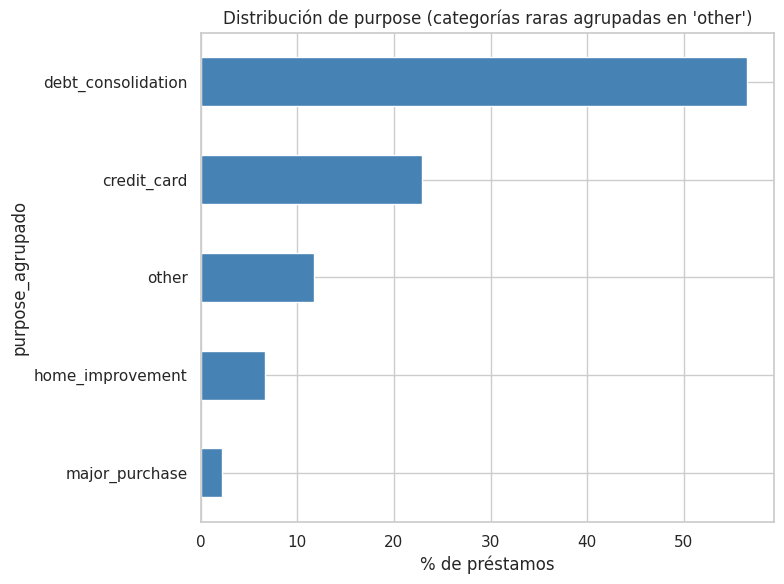

In [ ]:

umbral = 0.02
freqs = df['purpose'].value_counts(normalize=True)
categorias_raras = freqs[freqs < umbral].index
df['purpose_agrupado'] = df['purpose'].where(~df['purpose'].isin(categorias_raras), 'other')
print(df['purpose_agrupado'].value_counts(normalize=True))

purpose_pct = df["purpose_agrupado"].value_counts(normalize=True) * 100  # <- acá el cambio

fig, ax = plt.subplots(figsize=(8, 6))
purpose_pct.plot(kind="barh", ax=ax, color="steelblue")
ax.set_xlabel("% de préstamos")
ax.set_title("Distribución de purpose (categorías raras agrupadas en 'other')")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

#### 2.3 Variable `dti` — outliers y sentinelas

Contamos la proporción del DTI (capacidad de pago), que nos dice la relación entre la deuda mensual del prestatario y su ingreso mensual expresada en porcentaje.

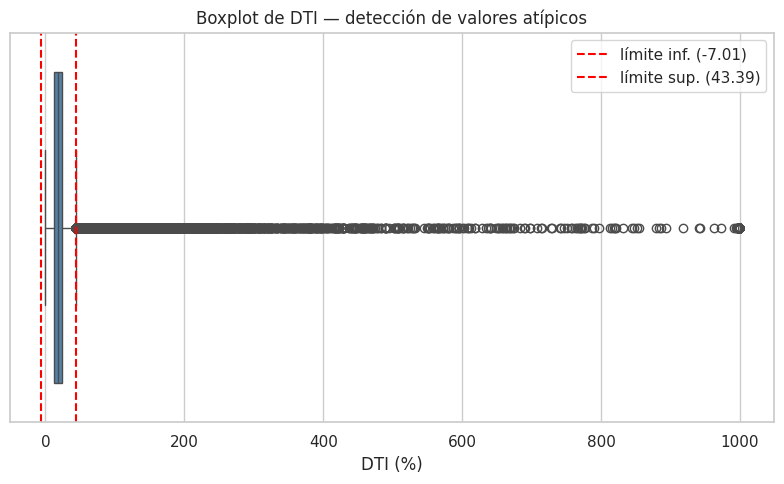

In [ ]:
Q1, Q3 = df['dti'].quantile([0.25, 0.75])
IQR = Q3 - Q1
lim_inf, lim_sup = Q1 - 1.5*IQR, Q3 + 1.5*IQR

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(x=df["dti"], ax=ax, color="steelblue")
ax.axvline(lim_inf, color="red", linestyle="--", label=f"límite inf. ({lim_inf:.2f})")
ax.axvline(lim_sup, color="red", linestyle="--", label=f"límite sup. ({lim_sup:.2f})")
ax.set_xlabel("DTI (%)")
ax.set_title("Boxplot de DTI — detección de valores atípicos")
ax.legend()
plt.tight_layout()
plt.show()

El boxplot muestra que la mayoría de los prestatarios tiene un DTI concentrado en una caja angosta, pegada a los valores bajos. Las líneas rojas marcan los límites calculados con el IQR (-7.01 y 43.39): todo lo que cae fuera de ese rango se marca como "atípico". **Vale notar que ese límite superior (43.39%) coincide casi exactamente con el umbral real que usa la industria crediticia para considerar deuda de alto riesgo (43%)**, el límite clásico de "Qualified Mortgage" en EE.UU.) — lo que valida que el cálculo no es un número arbitrario. Aun así, se ve una cola larga y densa de puntos que se extiende sin parar hasta 999, muy por fuera de ese límite.

### Sin embargo, no toda esa cola representa el mismo tipo de problema. Antes de decidir qué hacer con estos valores, conviene revisar qué hay realmente detrás de ellos.

In [ ]:
print(df['dti'].value_counts().loc[lambda s: s.index >= 900].sort_index())
print(df['dti'].value_counts().loc[lambda s: s.index < 0].sort_index())

dti
917.87      1
941.46      1
942.17      1
962.83      1
973.17      1
991.57      1
994.40      1
995.17      1
995.60      1
999.00    135
Name: count, dtype: int64
dti
-1.0    2
Name: count, dtype: int64


### Complementando este análsis se confirman 2 sentinelas no detectados por el boxplot/IQR:

**-1: valor imposible (DTI no puede ser negativo), con 2 registros.** Queda dentro del límite inferior calculado (-7.01), así que el boxplot no lo marca como atípico.
999: confirmado como código de "no disponible" y no una medición real, con 135 registros — value_counts() muestra que se repite exactamente 135 veces, mientras que **todo el resto de la cola alta (917–998) aparece una sola vez cada valor. Esa repetición exacta es la firma de un placeholder, no de datos continuos.**

Conclusión: el boxplot/IQR solo no alcanza para limpiar esta variable — hace falta una regla de negocio aparte para capturar los sentinelas, y un umbral de plausibilidad (no el IQR) para el resto de la cola.

In [ ]:
print("NaN originales en dti (antes de cualquier limpieza):", df['dti'].isna().sum())

NaN originales en dti (antes de cualquier limpieza): 1744


In [ ]:
df_clean = df.copy()

# Indicador de "faltaba" (antes de tocar el valor, para no perder la señal)
df_clean['dti_missing'] = df_clean['dti'].isin([-1, 999]).astype(int)

# Sentinelas -> NaN
n_sentinela_neg = (df_clean['dti'] == -1).sum()
n_sentinela_999 = (df_clean['dti'] == 999).sum()
df_clean.loc[df_clean['dti'].isin([-1, 999]), 'dti'] = np.nan

# Umbral de negocio para el resto de la cola implausible (no el IQR puro)
UMBRAL_DTI_MAX = 100
n_umbral = (df_clean['dti'] > UMBRAL_DTI_MAX).sum()
df_clean.loc[df_clean['dti'] > UMBRAL_DTI_MAX, 'dti'] = np.nan
df_clean['dti_missing'] = ((df_clean['dti_missing'] == 1) | (df_clean['dti'].isna())).astype(int)

# Imputación por mediana (robusta a los outliers reales que sí quedan, 45-100%)
mediana_dti = df_clean['dti'].median()
df_clean['dti'] = df_clean['dti'].fillna(mediana_dti)

print(f"-1 -> NaN: {n_sentinela_neg}")
print(f"999 -> NaN: {n_sentinela_999}")
print(f"> {UMBRAL_DTI_MAX} -> NaN: {n_umbral}")
print(f"Total marcado como dti_missing: {df_clean['dti_missing'].sum()}")
print(f"Mediana usada para imputar: {mediana_dti:.2f}")
print(f"NaN restantes en dti: {df_clean['dti'].isna().sum()}")  # debería ser 0

-1 -> NaN: 2
999 -> NaN: 135
> 100 -> NaN: 2426
Total marcado como dti_missing: 4307
Mediana usada para imputar: 17.82
NaN restantes en dti: 0


Tras aplicar la limpieza, dti queda sin sentinelas ni valores implausibles: se convirtieron a NaN los 2 registros con -1, los 135 con 999, y los 2,426 por encima del umbral de 100%. **Sumado a los 1,744 valores que ya venían como faltantes en el dataset original, el total marcado como dti_missing es 4,307 (~0.2% del dataset).**
### Todos esos casos se imputaron con la mediana (17.82%), preservando la señal de "faltaba" en la columna dti_missing para que el modelo pueda usarla si resulta relevante.

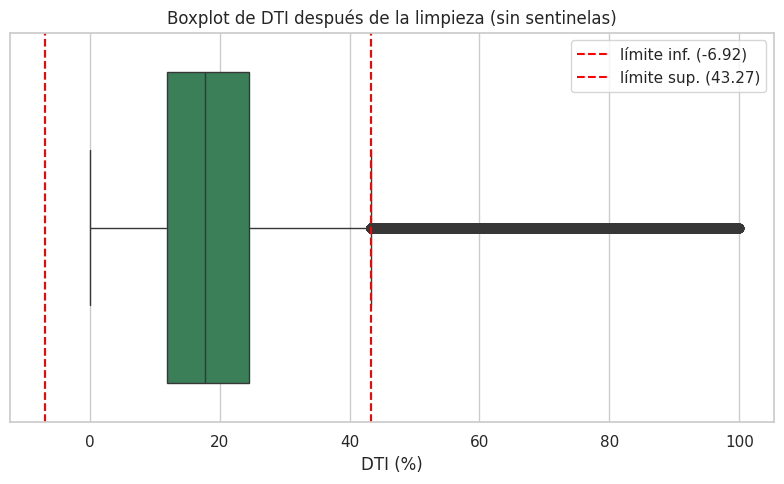

In [ ]:
Q1_clean, Q3_clean = df_clean['dti'].quantile([0.25, 0.75])
IQR_clean = Q3_clean - Q1_clean
lim_inf_clean, lim_sup_clean = Q1_clean - 1.5*IQR_clean, Q3_clean + 1.5*IQR_clean

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(x=df_clean["dti"], ax=ax, color="seagreen")
ax.axvline(lim_inf_clean, color="red", linestyle="--", label=f"límite inf. ({lim_inf_clean:.2f})")
ax.axvline(lim_sup_clean, color="red", linestyle="--", label=f"límite sup. ({lim_sup_clean:.2f})")
ax.set_xlabel("DTI (%)")
ax.set_title("Boxplot de DTI después de la limpieza (sin sentinelas)")
ax.legend()
plt.tight_layout()
plt.show()

## 3. Definición de la variable objetivo

Se colapsa `loan_status` en una variable binaria y se excluyen los préstamos cuyo desenlace
aún no está definido (`Current`, `In Grace Period`, `Late (16-30 days)`, `Late (31-120 days)`),
para evitar sesgo de censura (ver `proposal.md`, sección 5 y 8).

A partir de acá se trabaja sobre `df_clean` (sección 2), no sobre `df`: así `df_model` hereda
automáticamente el `dti` ya limpio, `purpose_agrupado` y `addr_region`.


In [ ]:
print("Distribución original de loan_status:")
print(df_clean["loan_status"].value_counts(dropna=False))

MALOS = ["Charged Off", "Default"]
BUENOS = ["Fully Paid"]

df_model = df_clean[df_clean["loan_status"].isin(MALOS + BUENOS)].copy()
df_model["target"] = df_model["loan_status"].isin(MALOS).astype(int)

print(f"\nFilas excluidas por estado no definitivo: {len(df_clean) - len(df_model):,}")
print(f"Filas para modelado: {len(df_model):,}")


Distribución original de loan_status:
loan_status
Fully Paid                                             1076751
Current                                                 878317
Charged Off                                             268559
Late (31-120 days)                                       21467
In Grace Period                                           8436
Late (16-30 days)                                         4349
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     40
NaN                                                         33
Name: count, dtype: int64

Filas excluidas por estado no definitivo: 915,351
Filas para modelado: 1,345,350


**Nota:** las categorías "Does not meet the credit policy" corresponden a préstamos antiguos que, aunque ya tienen un desenlace definitivo (pagado o impago), fueron originados bajo criterios de aprobación distintos a los del resto del dataset (Lending Club cambió sus políticas de crédito con el tiempo). Se excluyen junto con los estados no definitivos para no mezclar reglas de originación distintas dentro del set de modelado.

### El target se define como 1 si el préstamo no se pagó (malo), 0 si se pagó completo (bueno).

## 4. Número de filas, columnas y tipos de datos

In [ ]:
print(f"Shape (post-filtro de target): {df_model.shape}")
df_model.dtypes.value_counts()


Shape (post-filtro de target): (1345350, 32)


object     16
float64    14
int64       2
Name: count, dtype: int64

**Nota:** los 14 `float64` son las variables numéricas continuas (`dti`, `loan_amnt`, `annual_inc`, `mort_acc`, `revol_bal`, `revol_util`, los rangos de FICO, etc.); los 16 `object` agrupan tanto las categóricas estandarizadas (`purpose`, `grade`, `home_ownership`, `term`, etc.) como las fechas que todavía están como texto (`issue_d`, `earliest_cr_line`, recién se convierten a datetime en la sección 10) y el texto libre `emp_title`; los 2 `int64` son los conteos/flags exactos, como `target`.

In [ ]:
df_model.dtypes.astype(str).sort_values().to_frame(name="dtype")

,dtype
dti,float64
loan_amnt,float64
mort_acc,float64
int_rate,float64
total_acc,float64
revol_util,float64
revol_bal,float64
pub_rec,float64
open_acc,float64
annual_inc,float64


## 5. Porcentaje de valores faltantes por variable

In [ ]:
missing_pct = (df_model.isna().mean() * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]
missing_pct.to_frame(name="% faltante")


,% faltante
emp_title,6.376854
emp_length,5.836102
mort_acc,3.514401
revol_util,0.063701
inq_last_6mths,0.000074


**Nota sobre `dti`:** no aparece en esta tabla porque ya se limpió e imputó en la sección 2.3 (`df_clean`), por lo que `isna()` da 0% acá. Eso no significa que `dti` no haya tenido problemas: su tasa real de valores faltantes/implausibles (sentinelas `-1` y `999`, valores >100%, y los NaN originales) fue de **4,307 registros sobre 2,260,701 filas cargadas (~0.19%)**, documentada en la sección 2.3 junto con el criterio usado para tratarlos (indicador `dti_missing` + imputación por mediana).

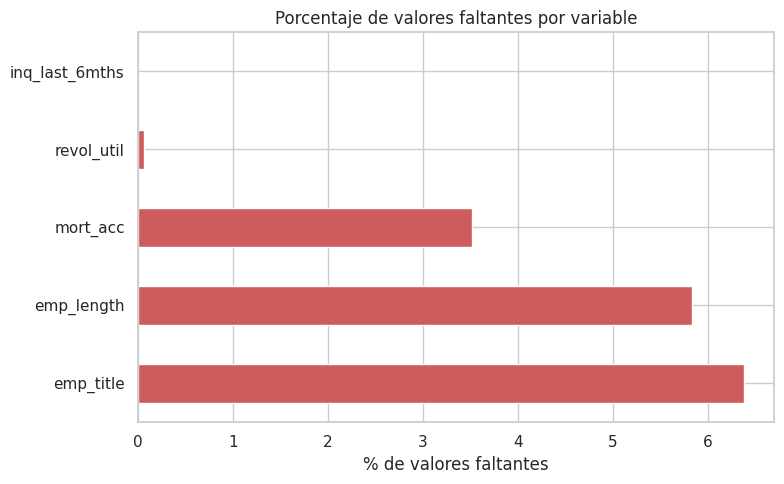

In [ ]:
# Visualización 1: % de faltantes por variable
fig, ax = plt.subplots(figsize=(8, 5))
missing_pct.plot(kind="barh", ax=ax, color="indianred")
ax.set_xlabel("% de valores faltantes")
ax.set_title("Porcentaje de valores faltantes por variable")
plt.tight_layout()
plt.show()


Según el gráfico de barras, la variable con más faltantes es `emp_title` (6.38%), seguida de `emp_length` (5.84%) y `mort_acc` (3.51%); `revol_util` e `inq_last_6mths` son prácticamente insignificantes (<0.1%). Ninguna alcanza niveles graves, resultado esperable tras excluir en la sección 7 las columnas "joint"/"sec_app_*" (>90% de faltantes). `emp_title` además ya está fuera del baseline por su alta cardinalidad, así que su faltante no afecta al modelo; el resto se resolverá más adelante con la imputación simple (mediana/moda) del pipeline del baseline (sección 10).

## 6. Distribución de la variable objetivo

target
0    80.035009
1    19.964991
Name: proportion, dtype: float64


/tmp/ipykernel_58/1434509479.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="target", data=df_model, ax=ax, palette=["#4C72B0", "#C44E52"])
/tmp/ipykernel_58/1434509479.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Bueno (Fully Paid)", "Malo (Default/Charged Off)"])


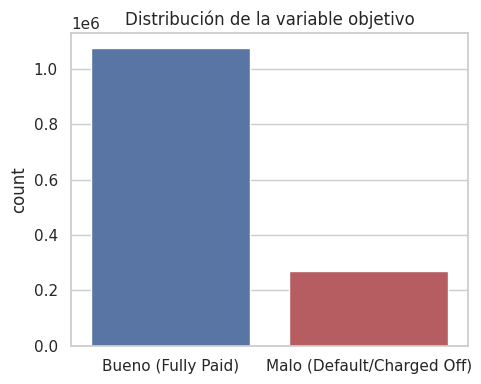

In [ ]:
target_counts = df_model["target"].value_counts(normalize=True) * 100
print(target_counts)

# Visualización 2: distribución del target
fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(x="target", data=df_model, ax=ax, palette=["#4C72B0", "#C44E52"])
ax.set_xticklabels(["Bueno (Fully Paid)", "Malo (Default/Charged Off)"])
ax.set_title("Distribución de la variable objetivo")
ax.set_xlabel("")
plt.tight_layout()
plt.show()


**Lectura esperada:** se anticipa un fuerte desbalance de clases (~15-20% de préstamos en default/charged off),
lo cual justifica usar AUC-PR y KS como métricas principales en vez de accuracy (ver `proposal.md`, sección 9).


## 7. Al menos 5 visualizaciones

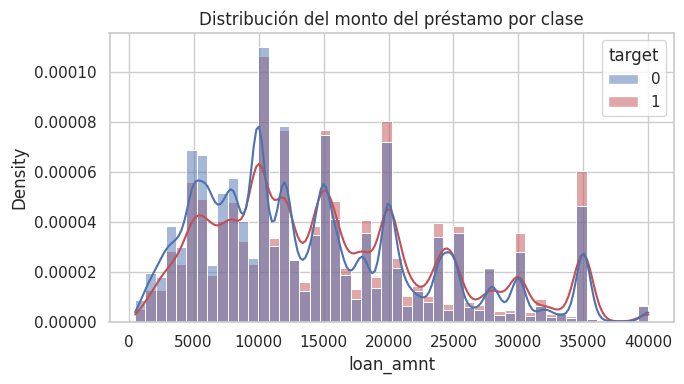

In [ ]:
# Visualización 3: distribución de loan_amnt por clase
fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(data=df_model, x="loan_amnt", hue="target", bins=50, kde=True, ax=ax,
             palette=["#4C72B0", "#C44E52"], stat="density", common_norm=False)
ax.set_title("Distribución del monto del préstamo por clase")
plt.tight_layout()
plt.show()


**Análisis de distribución:** las distribuciones de `loan_amnt` para ambas clases se superponen fuertemente y comparten el mismo patrón multimodal, con picos en montos "redondos" (10k, 15k, 20k, 25k, 30k, 35k) — un reflejo de cómo se solicitan los préstamos, no una diferencia entre clases. Las curvas KDE de "Bueno" y "Malo" van casi pegadas en casi todo el rango, lo que sugiere que `loan_amnt` por sí solo tiene poco poder discriminativo sobre el riesgo de default (consistente con su correlación baja con el target, 0.07, vista más adelante en la matriz de correlación).

/tmp/ipykernel_58/684857000.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Bueno", "Malo"])


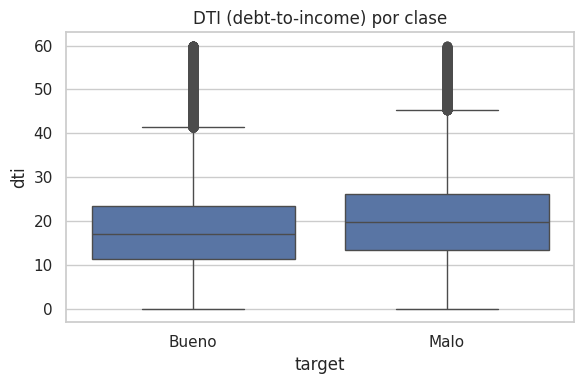

In [ ]:
# Visualización 4: dti (debt-to-income) por clase (boxplot, con recorte de outliers extremos)
fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(x="target", y="dti", data=df_model[df_model["dti"].between(0, 60)], ax=ax)
ax.set_xticklabels(["Bueno", "Malo"])
ax.set_title("DTI (debt-to-income) por clase")
plt.tight_layout()
plt.show()


Para este análisis, **la mediana de DTI es más alta en el grupo "Malo" (20-21) que en "Bueno" (17-18)**, y toda la distribución está desplazada hacia valores mayores (Q1 y Q3 más altos). Esto es consistente con la lógica esperada: a mayor proporción de deuda sobre ingreso, menor margen para cubrir la cuota del préstamo ante un imprevisto, lo que se traduce en mayor riesgo de default (patrón que se confirma más adelante con la correlación positiva entre `dti` y `target` en la matriz de correlación).

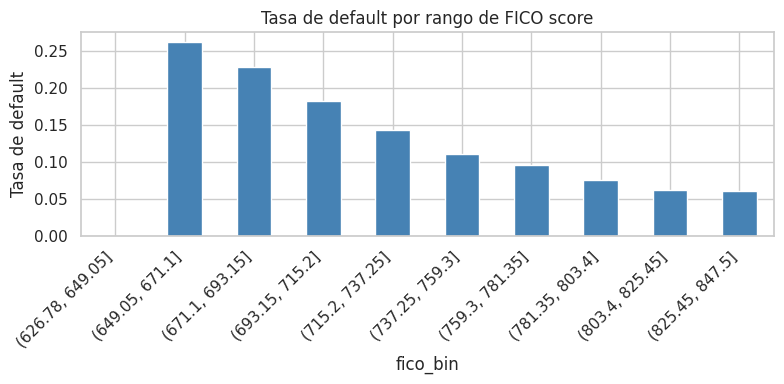

In [ ]:
# Visualización 5: tasa de default por rango de FICO
df_model["fico_avg"] = (df_model["fico_range_low"] + df_model["fico_range_high"]) / 2
df_model["fico_bin"] = pd.cut(df_model["fico_avg"], bins=10)

fico_default_rate = df_model.groupby("fico_bin", observed=True)["target"].mean()

fig, ax = plt.subplots(figsize=(8, 4))
fico_default_rate.plot(kind="bar", ax=ax, color="steelblue")
ax.set_ylabel("Tasa de default")
ax.set_title("Tasa de default por rango de FICO score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


La tasa de default cae de forma consistente a medida que sube el FICO score, de ~26% en el rango más bajo (626-649) a ~6% en los más altos (>800), sin inversiones — el comportamiento esperado, ya que FICO está diseñado como score de riesgo crediticio, y **confirma a fico_avg como un predictor individual fuerte**. Esta caída tan marcada a nivel de grupo contrasta con su correlación de -0.13 vista en la matriz, porque esa correlación se calcula préstamo por préstamo (donde hay superposición entre "buenos" y "malos" en casi todo el rango), mientras que el gráfico promedia por bin y así revela con claridad la tendencia real.
#### Por lo que se sugiere que un modelo no lineal podría aprovechar esta señal mejor que la regresión logística del baseline.

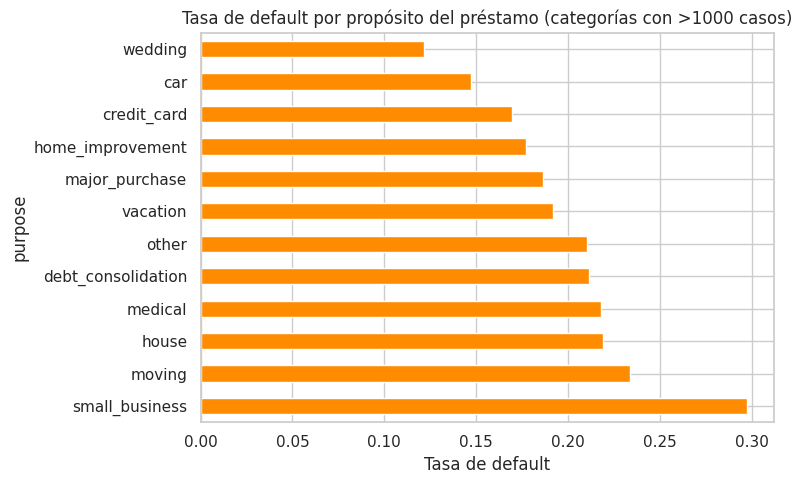

In [ ]:
# Visualización 6: tasa de default por propósito del préstamo
purpose_default = df_model.groupby("purpose")["target"].agg(["mean", "count"]).sort_values("mean", ascending=False)
purpose_default = purpose_default[purpose_default["count"] > 1000]  # descartar categorías con muy pocos casos

fig, ax = plt.subplots(figsize=(8, 5))
purpose_default["mean"].plot(kind="barh", ax=ax, color="darkorange")
ax.set_xlabel("Tasa de default")
ax.set_title("Tasa de default por propósito del préstamo (categorías con >1000 casos)")
plt.tight_layout()
plt.show()


**Análisis:** `small_business` tiene la tasa de default más alta (30%), notablemente por encima del resto de categorías — coherente con que un préstamo de negocio depende del éxito de esa empresa, un flujo de caja más incierto que el de un ingreso personal fijo. En el otro extremo, `wedding` y `car` muestran las tasas más bajas (~13-15%), asociadas a montos más acotados y planificados. Esta brecha de más del doble entre categorías confirma que `purpose` aporta señal real de riesgo, lo que respalda su inclusión (agrupada) como feature en el baseline.

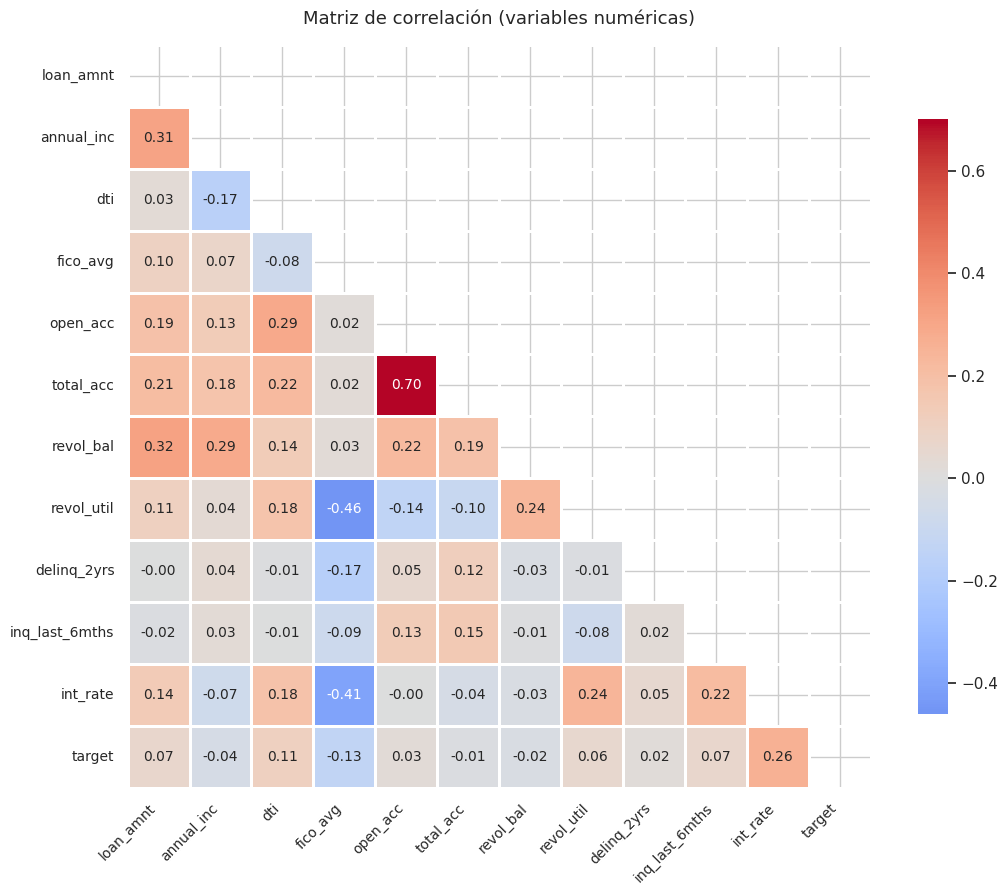

In [ ]:
# Visualización 7: matriz de correlación entre variables numéricas
num_cols = ["loan_amnt", "annual_inc", "dti", "fico_avg", "open_acc",
            "total_acc", "revol_bal", "revol_util", "delinq_2yrs",
            "inq_last_6mths", "int_rate", "target"]

corr = df_model[num_cols].corr()

# Máscara para no repetir la mitad espejada (la matriz es simétrica: corr[i,j] == corr[j,i])
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=1, linecolor="white",
            annot_kws={"size": 10}, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("Matriz de correlación (variables numéricas)", fontsize=13, pad=15)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=10)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)
plt.tight_layout()
plt.show()

La matriz de correlación no muestra problemas fuertes de multicolinealidad entre las variables numéricas, salvo open_acc/total_acc (0.70), algo esperable porque ambas cuentan líneas de crédito; fico_avg baja cuando suben revol_util e int_rate, lo cual es coherente con el comportamiento crediticio real, y **la correlación más alta con el target es justamente int_rate (0.26), lo que tiene sentido porque esa tasa ya incorpora buena parte del scoring de riesgo propio de LendingClub**, mientras que el resto de variables por separado (dti, fico_avg, loan_amnt, annual_inc) muestran correlaciones débiles con el target, sin que ninguna domine por sí sola.

## 8. Identificación de outliers y registros sospechosos (consolidación)

`addr_state`, `purpose` y `dti` ya se revisaron a fondo en la sección 2 (con evidencia de `value_counts()` para los sentinelas de `dti`, y el criterio de agrupamiento de `purpose`). Acá se revisan las variables numéricas restantes que todavía no tienen un criterio de limpieza definido.


In [ ]:
print("annual_inc — estadísticos:")
print(df_model["annual_inc"].describe())
print(f"\nPréstamos con annual_inc > $1,000,000: {(df_model['annual_inc'] > 1_000_000).sum():,}")

print("\ndti — verificación post-limpieza (ver sección 2.3, df_clean):")
print(df_model["dti"].describe())
print(f"Préstamos con dti negativo: {(df_model['dti'] < 0).sum():,}  (debería ser 0, ya se limpió)")
print(f"Préstamos con dti > 100: {(df_model['dti'] > 100).sum():,}  (debería ser 0, ya se limpió)")
print(f"Registros marcados dti_missing (sentinela/umbral/original, ya imputados): {df_model['dti_missing'].sum():,}")

print(f"\nPréstamos con revol_util > 150% (posible error de captura): {(df_model['revol_util'] > 150).sum():,}")


annual_inc — estadísticos:
count    1.345350e+06
mean     7.624757e+04
std      6.992485e+04
min      0.000000e+00
25%      4.578000e+04
50%      6.500000e+04
75%      9.000000e+04
max      1.099920e+07
Name: annual_inc, dtype: float64

Préstamos con annual_inc > $1,000,000: 290

dti — verificación post-limpieza (ver sección 2.3, df_clean):
count    1.345350e+06
mean     1.818413e+01
std      8.675471e+00
min      0.000000e+00
25%      1.179000e+01
50%      1.762000e+01
75%      2.404000e+01
max      1.000000e+02
Name: dti, dtype: float64
Préstamos con dti negativo: 0  (debería ser 0, ya se limpió)
Préstamos con dti > 100: 0  (debería ser 0, ya se limpió)
Registros marcados dti_missing (sentinela/umbral/original, ya imputados): 909

Préstamos con revol_util > 150% (posible error de captura): 20


**Decisión:** `dti` ya fue limpiado en la sección 2.3 (sentinelas `-1`/`999` y valores >100% imputados con la mediana, con el indicador `dti_missing` preservado) y `purpose` ya fue agrupado en la sección 2.2 — ambos se propagan automáticamente a `df_model` porque este se construye sobre `df_clean` (sección 3). Quedan como candidatos pendientes para `02_limpieza_features.ipynb`: los registros con `annual_inc` extremo (>$1M, 290 casos) y `revol_util` > 150% (20 casos, posible error de captura), que todavía no tienen una regla de limpieza definida.


## 9. Discusión inicial de sesgos, leakage y limitaciones

**Leakage:**
- Se excluyeron explícitamente todas las variables generadas después del desembolso del préstamo
  (`total_pymnt`, `recoveries`, `last_pymnt_d`, `hardship_*`, `settlement_*`, etc.), ya que revelan directamente el desenlace.
- `grade`, `sub_grade` e `int_rate` se mantienen como "zona gris": están disponibles al momento de originación,
  pero son producto del propio modelo de scoring de Lending Club. Se entrenará con y sin estas variables
  para medir cuánto del desempeño depende de "copiar" la decisión de LC.

**Sesgos:**
- El dataset solo contiene préstamos **aprobados** por Lending Club (no hay información de solicitudes rechazadas),
  por lo que cualquier modelo entrenado aquí hereda el sesgo de selección del proceso de aprobación original.
- Variables como `addr_state` o `home_ownership` pueden actuar como proxies de variables socioeconómicas
  sensibles; se documentará si el modelo genera disparidades relevantes por segmento en el análisis de errores.
- El comportamiento de default varía por ciclo económico (ej. prestamos originados antes/durante la crisis
  de 2008-2009 vs. después); esto motiva el split temporal (out-of-time) descrito en `proposal.md`.

**Limitaciones:**
- No se dispone de las solicitudes rechazadas, por lo que no se puede modelar el proceso de aprobación completo,
  solo el riesgo condicional a haber sido aprobado.
- Variables de texto libre (`emp_title`, `desc`) no se usarán en el baseline por su alta cardinalidad y ruido;
  se evaluará su potencial en iteraciones posteriores.


## 10. Baseline simple

Regresión logística con las variables "incluidas" (sin `grade`/`sub_grade`/`int_rate`), split **temporal**
(no aleatorio) usando `issue_d`, siguiendo el plan de validación de `proposal.md`.


In [ ]:
df_model["issue_d"] = pd.to_datetime(df_model["issue_d"], format="%b-%Y")
df_model["issue_year"] = df_model["issue_d"].dt.year

train = df_model[df_model["issue_year"].between(2015, 2017)]
valid = df_model[df_model["issue_year"] == 2018]

print(f"Train: {len(train):,} filas | Valid: {len(valid):,} filas")
print(f"Tasa de default train: {train['target'].mean():.3f} | valid: {valid['target'].mean():.3f}")


Train: 837,972 filas | Valid: 56,318 filas
Tasa de default train: 0.219 | valid: 0.158


In [ ]:
FEATURES_NUM = ["loan_amnt", "annual_inc", "dti", "dti_missing", "fico_avg", "open_acc",
                "total_acc", "revol_bal", "revol_util", "delinq_2yrs",
                "inq_last_6mths", "mort_acc"]
FEATURES_CAT = ["term", "purpose_agrupado", "emp_length", "home_ownership",
                "verification_status", "application_type"]

X_train, y_train = train[FEATURES_NUM + FEATURES_CAT], train["target"]
X_valid, y_valid = valid[FEATURES_NUM + FEATURES_CAT], valid["target"]

preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]), FEATURES_NUM),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]), FEATURES_CAT),
])

baseline = Pipeline([
    ("preprocessor", preprocessor),
    ("clf", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)),
])

baseline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](18,)","['loan_amnt','annual_inc','dti',...,'home_ownership','verification_status', 'application_type']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,18
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder

**Análisis Pipeline:** el pipeline entrenado combina 12 variables numéricas (imputadas con la mediana y estandarizadas) y 6 categóricas (imputadas con la moda y codificadas con one-hot), que tras el encoding se expanden a 28 columnas binarias — sumando 40 features en total que alimentan la regresión logística. El diagrama confirma que el pipeline corrió y se entrenó sin errores, tal como estaba definido en el código.

In [ ]:
y_pred_proba = baseline.predict_proba(X_valid)[:, 1]
y_pred = baseline.predict(X_valid)

print(f"AUC-ROC: {roc_auc_score(y_valid, y_pred_proba):.3f}")
print(f"AUC-PR (métrica principal): {average_precision_score(y_valid, y_pred_proba):.3f}")
print()
print(classification_report(y_valid, y_pred, target_names=["Bueno", "Malo"]))
print()
print("Matriz de confusión:")
print(confusion_matrix(y_valid, y_pred))


AUC-ROC: 0.682
AUC-PR (métrica principal): 0.272

              precision    recall  f1-score   support

       Bueno       0.90      0.69      0.78     47444
        Malo       0.25      0.57      0.35      8874

    accuracy                           0.67     56318
   macro avg       0.57      0.63      0.56     56318
weighted avg       0.79      0.67      0.71     56318


Matriz de confusión:
[[32653 14791]
 [ 3829  5045]]


**Lectura inicial:** el baseline (regresión logística, sin variables "zona gris") logra un AUC-PR de 0.272, cerca de 1.7 veces el piso de un modelo sin señal (~0.158, la proporción real de "Malos"), confirmando que hay señal real aunque limitada — el resultado esperado y sano para un primer piso de comparación honesto. Las siguientes mejoras ya están planeadas: agregar `grade`/`sub_grade`/`int_rate` (la variable con más correlación individual con el target), probar modelos no lineales (random forest, gradient boosting) que capturen interacciones, y ajustar el umbral de decisión para mejorar precision sin sacrificar tanto recall.